![header](../figures/logos_partenaires._cmems_se.jpg)

# Benchmark DUACS sea surface height maps

<div style="text-align: right"><i> 2023-04-27 DUACS_SSH_BENCHMARK_DEMO </i></div>

***
**Authors:**  CLS & Datlas <br>
**Copyright:** 2023 CLS & Datlas <br>
**License:** MIT

<div class="alert alert-block alert-success">
<h1><center>Benchmark of DUACS sea surface height maps</center></h1>
<h5> The notebook aims to evaluate the sea surface height maps produced by the DUACS system. </h5>
    <h5> These maps are equivalent to the SEALEVEL_GLO_PHY_L4_MY_008_047 product distributed by the Copernicus Marine Service, except that a nadir altimeter (SARAL/Altika, SEALEVEL_GLO_PHY_L3_MY_008_062 product) has been excluded from the mapping. </h5>
        <h5> We provide below a demonstration of the validation of these maps against the independent SSH data from the Saral/AltiKa altimeter distributed by CMEMS </h5>
</div>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Cell" and select "Run All Above Selected Cell".<br>
***


<div class="alert alert-danger" role="alert">

<h3>Learning outcomes</h3>

At the end of this notebook you will know:
<ul>
  <li>How you can evaluated sea surface height maps with independent alongtrack data: statistical and spectral analysis</li>
</ul>
    
</div>

In [1]:
#%pip install hvplot
#%pip install --dry-run 'numpy<2' numba

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('..')
from src.mod_plot import *
from src.mod_stat import *
from src.mod_spectral import *
from src.mod_interp import *
from src.mod_intervals import *
from glob import glob
import numpy as np
import os

In [4]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

<div class="alert alert-info" role="alert">

<h2>0. Parameters</h2>

</div>

In [5]:
time_min = '2023-01-15'                                        # time min for analysis
time_max = '2023-12-15'                                        # time max for analysis

output_dir = '../results'                                      # output directory path
os.system(f'mkdir -p {output_dir}')
method_name = 'DUACS'

stat_output_filename = f'{output_dir}/stat_ssh_glo12.nc'  # output statistical analysis filename
lambda_min = 65.                                               # minimun spatial scale in kilometer to consider on the filtered signal
lambda_max = 500.                                              # maximum spatial scale in kilometer to consider on the filtered signal
psd_output_filename = f'{output_dir}/psd_ssh_glo12.nc'    # output spectral analysis filename
segment_lenght = 1000.                                         # spectral parameer: along-track segment lenght in kilometer to consider in the spectral analysis

<div class="alert alert-info" role="alert">

<h2>1. Input files</h2>

</div>

## Sea Surface Height from Saral/AltiKa

In [6]:
list_of_file = sorted(glob('/Odyssey/public/altimetry_traces/processed_2023_global_4/dl/ref/*/**/*2024*/2023/**/*.nc'))

ds_alg = xr.open_mfdataset(list_of_file)
ds_alg = ds_alg.where((ds_alg.time >= np.datetime64(time_min)) & (ds_alg.time <=  np.datetime64(time_max)), drop=True)[["sla_filtered", "sla_unfiltered", "mdt", "lwe"]]
ds_alg['ssh'] = ds_alg.sla_unfiltered + ds_alg.mdt - ds_alg.lwe

## Sea Surface Height maps to evaluate

In [7]:
glo12_paths = '/Odyssey/public/glorys/mercator_forecast/glo12/R202*/'
ds_maps = get_preprocessed_rec_mercator_forecast(glo12_paths, leadtime_index=6)

ds_maps = ds_maps.sel(time=slice(time_min, time_max)).rename({'out':'ssh', 'lat':'latitude', 'lon':'longitude'})

#normalise because ssh has a different referential
ds_maps['ssh'] = ds_maps.ssh - ds_maps.ssh.mean(skipna=True) + ds_alg.ssh.mean(skipna=True)

In [8]:
m_var, s_var = ds_maps.ssh.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
m_var, s_var

(0.4375411316542645, 0.7156321787019326)

## Time restriction for methods with Intervals between leadtimes

In [9]:
# RESTRICT TIME TO 0.5 DAYS AROUND RECONSTRUCTED LEADTIMES
ds_alg = ds_alg.sel(time=restrict_time_alongtrack(ds_alg.time.values, ds_maps.time.values, days_offset=0.5))

## Very important manipulation in order to make DC21 notebooks work ! 

In [10]:
def ds_manip(ds):
    ds["longitude"] = (ds["longitude"] % 360).where(ds["longitude"] != 360, 0)
    lon_unique, index = np.unique(ds.coords["longitude"], return_index=True)
    ds = ds.isel(longitude=index)
    ds.latitude.attrs['units'] = 'degrees_north'
    ds.longitude.attrs['units'] = 'degrees_east'
    ds = ds.sortby(['time', 'longitude', 'latitude'])
    return ds

ds_maps = ds_manip(ds_maps)

#create and mdt dataset
mdt_maps = ds_manip(xr.open_dataset("/Odyssey/public/duacs/1993_2013/duacs_global_0.25deg_1993_2013_mdt.nc").expand_dims({'time': ds_maps.time.values}, axis=0))

<div class="alert alert-info" role="alert">

<h2>2. Statistical & Spectral Analysis </h2>

</div>

## 2.1 Interpolate sea surface height maps onto along-track positions

### 2.1.1 Additionally, interpolate mdt from ds_maps onto along-track positions -> changed /src/mod_interp.py

In [11]:
ds_interp = run_interpolation_plus(ds_maps, ds_alg, var_alongtrack='sla_unfiltered', var_rec='ssh', forecast_interval=True, num_threads=16)

# interpolate mdt on the dataset as well
ds_interp_mdt = run_interpolation_plus(mdt_maps, ds_alg, var_alongtrack='sla_unfiltered', var_rec='mdt', out_var='mdt_interpolated', forecast_interval=True)

2025-01-29 09:09:49 INFO     fetch data from 2023-01-17 00:00:00 to 2023-02-07 00:00:00
2025-01-29 09:10:22 INFO     fetch data from 2023-01-31 00:00:00 to 2023-03-07 00:00:00
2025-01-29 09:10:55 INFO     fetch data from 2023-02-28 00:00:00 to 2023-04-04 00:00:00
2025-01-29 09:11:28 INFO     fetch data from 2023-03-28 00:00:00 to 2023-05-02 00:00:00
2025-01-29 09:12:00 INFO     fetch data from 2023-04-25 00:00:00 to 2023-06-06 00:00:00
2025-01-29 09:12:23 INFO     fetch data from 2023-05-30 00:00:00 to 2023-07-04 00:00:00
2025-01-29 09:12:46 INFO     fetch data from 2023-06-27 00:00:00 to 2023-08-01 00:00:00
2025-01-29 09:13:09 INFO     fetch data from 2023-07-25 00:00:00 to 2023-09-05 00:00:00
2025-01-29 09:13:31 INFO     fetch data from 2023-08-29 00:00:00 to 2023-10-03 00:00:00
2025-01-29 09:13:55 INFO     fetch data from 2023-09-26 00:00:00 to 2023-11-07 00:00:00
2025-01-29 09:14:19 INFO     fetch data from 2023-10-31 00:00:00 to 2023-12-05 00:00:00
2025-01-29 09:14:43 INFO     fet

### 2.1.2 Now replace SLA from altimeters to SSH: SSH_altimeters = SLA_altimeters + MDT_interpolated

In [12]:
ds_interp['sla_unfiltered'] = ds_interp['sla_unfiltered'] + ds_interp_mdt['mdt_interpolated']
ds_interp['sla_filtered'] = ds_interp['sla_filtered'] + ds_interp_mdt['mdt_interpolated']
ds_interp['msla_interpolated'] = ds_interp['ssh_interpolated']
ds_interp = ds_interp.dropna('time')

## 2.2 Compute grid boxes statistics & statistics by regime (coastal, offshore low variability, offshore high variability)

Once the maps have been interpolated to the position of the along-track, it is possible to calculate different statistics on the time series SLA_alongtrack and SLA_maps. 

We propose below the following statistics: error variance maps (static by 1°x1° box), explained variance maps, temporal evolution of global error variance and explained variance. 

These statistics are also applied to the filtered signals focusing on the 65-500km scale range. A bandpass filter is applied before calculating the scores.  

In [13]:
compute_stat_scores(ds_interp, lambda_min, lambda_max, stat_output_filename, method_name, freq_out='1D', land_sea_mask='/Odyssey/public/data_challenge_ssh_ose/data/sad/land_water_mask_60.nc', variance_ssh='/Odyssey/public/data_challenge_ssh_ose/data/sad/variance_cmems_dt_allsat.nc', distance_to_nearest_coast='/Odyssey/public/data_challenge_ssh_ose/data/sad/distance_to_nearest_coastline_60.nc')

2025-01-29 09:15:12 INFO     Compute mapping error all scales


2025-01-29 09:15:12 INFO     Compute mapping error for scales between 65.0 and 500.0 km


Total RMSE= 0.15007471795451963 m
Total RMSE score= 0.8131345958441905 m


2025-01-29 09:15:28 INFO     Compute binning statistics
2025-01-29 09:15:32 INFO     Compute statistics by oceanic regime
2025-01-29 09:15:55 INFO     Stat file saved as: ../results/stat_ssh_glo12.nc


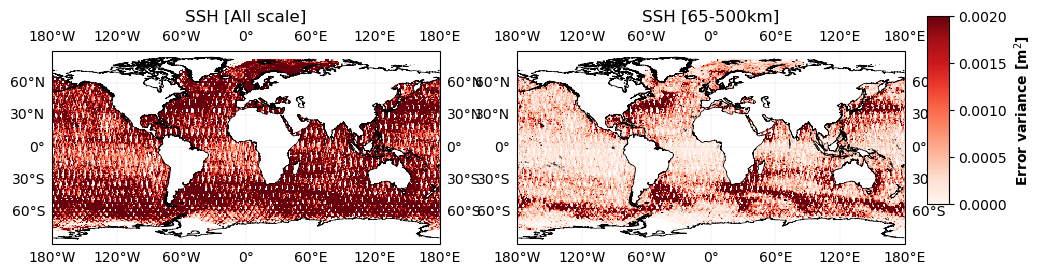

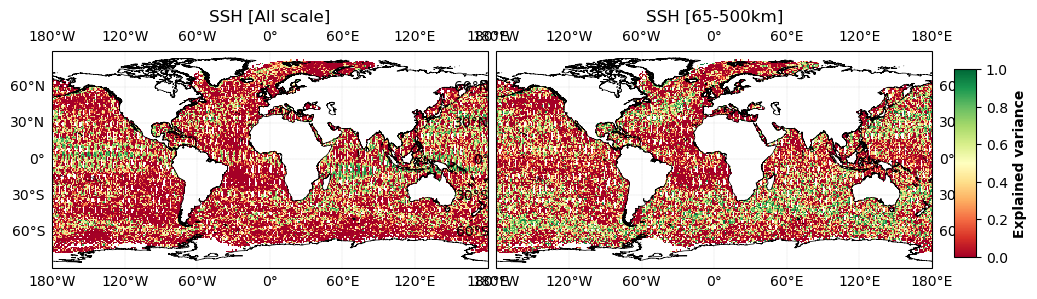

In [14]:
plot_stat_score_map_png(stat_output_filename)

In [15]:
plot_stat_score_timeseries(stat_output_filename)

:Layout
   .Overlay.I  :Overlay
      .Curve.All_scale :Curve   [time]   (timeserie_variance_mapping_err)
      .Curve.Filtered  :Curve   [time]   (timeserie_variance_mapping_err)
   .Overlay.II :Overlay
      .Curve.All_scale :Curve   [time]   (explained_variance_score)
      .Curve.Filtered  :Curve   [time]   (explained_variance_score)

### 2.2.1 I modified /src/mod_stat.py in order to add the computation of nRMSE score for mappieng err; I also modified /src/mod_plot.py in order to include RMSE and nRMSE score to the table

In [16]:
plot_stat_by_regimes(stat_output_filename)

,mapping_err_var [m²],mapping_err_rms,mapping_err_nrms_score,sla_unfiltered_var [m²],sla_unfiltered_rms,sla_unfiltered_nrms_score,mapping_err_filtered_var [m²],mapping_err_filtered_rms,mapping_err_filtered_nrms_score,sla_filtered_var [m²],sla_filtered_rms,sla_filtered_nrms_score,var_score_allscale,var_score_filtered
coastal,0.005639,0.145210,0.819191,0.327560,0.822466,0.819191,0.001246,0.035302,0.819191,0.002597,0.050962,0.819191,0.982785,0.520073
offshore_highvar,0.029863,0.217431,0.729266,0.329923,0.776921,0.729266,0.011085,0.105286,0.729266,0.025666,0.160958,0.729266,0.909484,0.568118
offshore_lowvar,0.004220,0.144720,0.819802,0.488858,0.797928,0.819802,0.001098,0.033137,0.819802,0.002354,0.048542,0.819802,0.991369,0.533444
equatorial_band,0.002687,0.131055,0.836817,0.055590,0.882098,0.836817,0.000503,0.022439,0.836817,0.000676,0.026029,0.836817,0.951661,0.254948
arctic,0.004903,0.166824,0.792279,0.013977,0.250341,0.792279,0.000759,0.027542,0.792279,0.000947,0.030788,0.792279,0.649226,0.199325
antarctic,0.003581,0.136926,0.829507,0.004002,1.202927,0.829507,0.000766,0.027708,0.829507,0.000680,0.026097,0.829507,0.105147,-0.126240


## 2.3 Compute Spectral scores

In [17]:
compute_psd_scores_v2(ds_interp, psd_output_filename, lenght_scale=segment_lenght,method_name=method_name)

2025-01-29 09:16:18 INFO     Segment computation...


2025-01-29 09:16:21 INFO     Spectral analysis...
2025-01-29 09:18:34 INFO     Saving ouput...
2025-01-29 09:18:41 INFO     PSD file saved as: ../results/psd_ssh_glo12.nc


Averaged effective resolution: 421.8550305032456 km


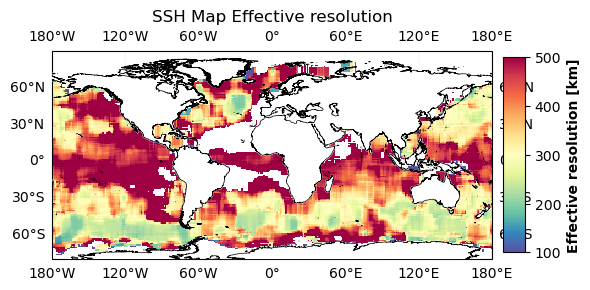

In [18]:
# Plot effective resolution
# Hvplot
# plot_effective_resolution(psd_output_filename)
# Matplotlib
plot_effective_resolution_png(psd_output_filename)

In [19]:
#plot_psd_scores(psd_output_filename)

The interactive plot above allows you to explore the spectral metrics by latitude / longitude box